🎨 Design System Initialized.
🔄 Loading Data...
✅ Data Ready.
   ...Plotting Network Map
   ...Plotting Heatmap
   ...Plotting Word Clouds
   ...Plotting Bar Charts
   ...Plotting Radar Charts
   ...Plotting Ego Networks
   ...Plotting Power Quadrant

✅ MASTER OVERHAUL COMPLETE. All 10+ figures generated.


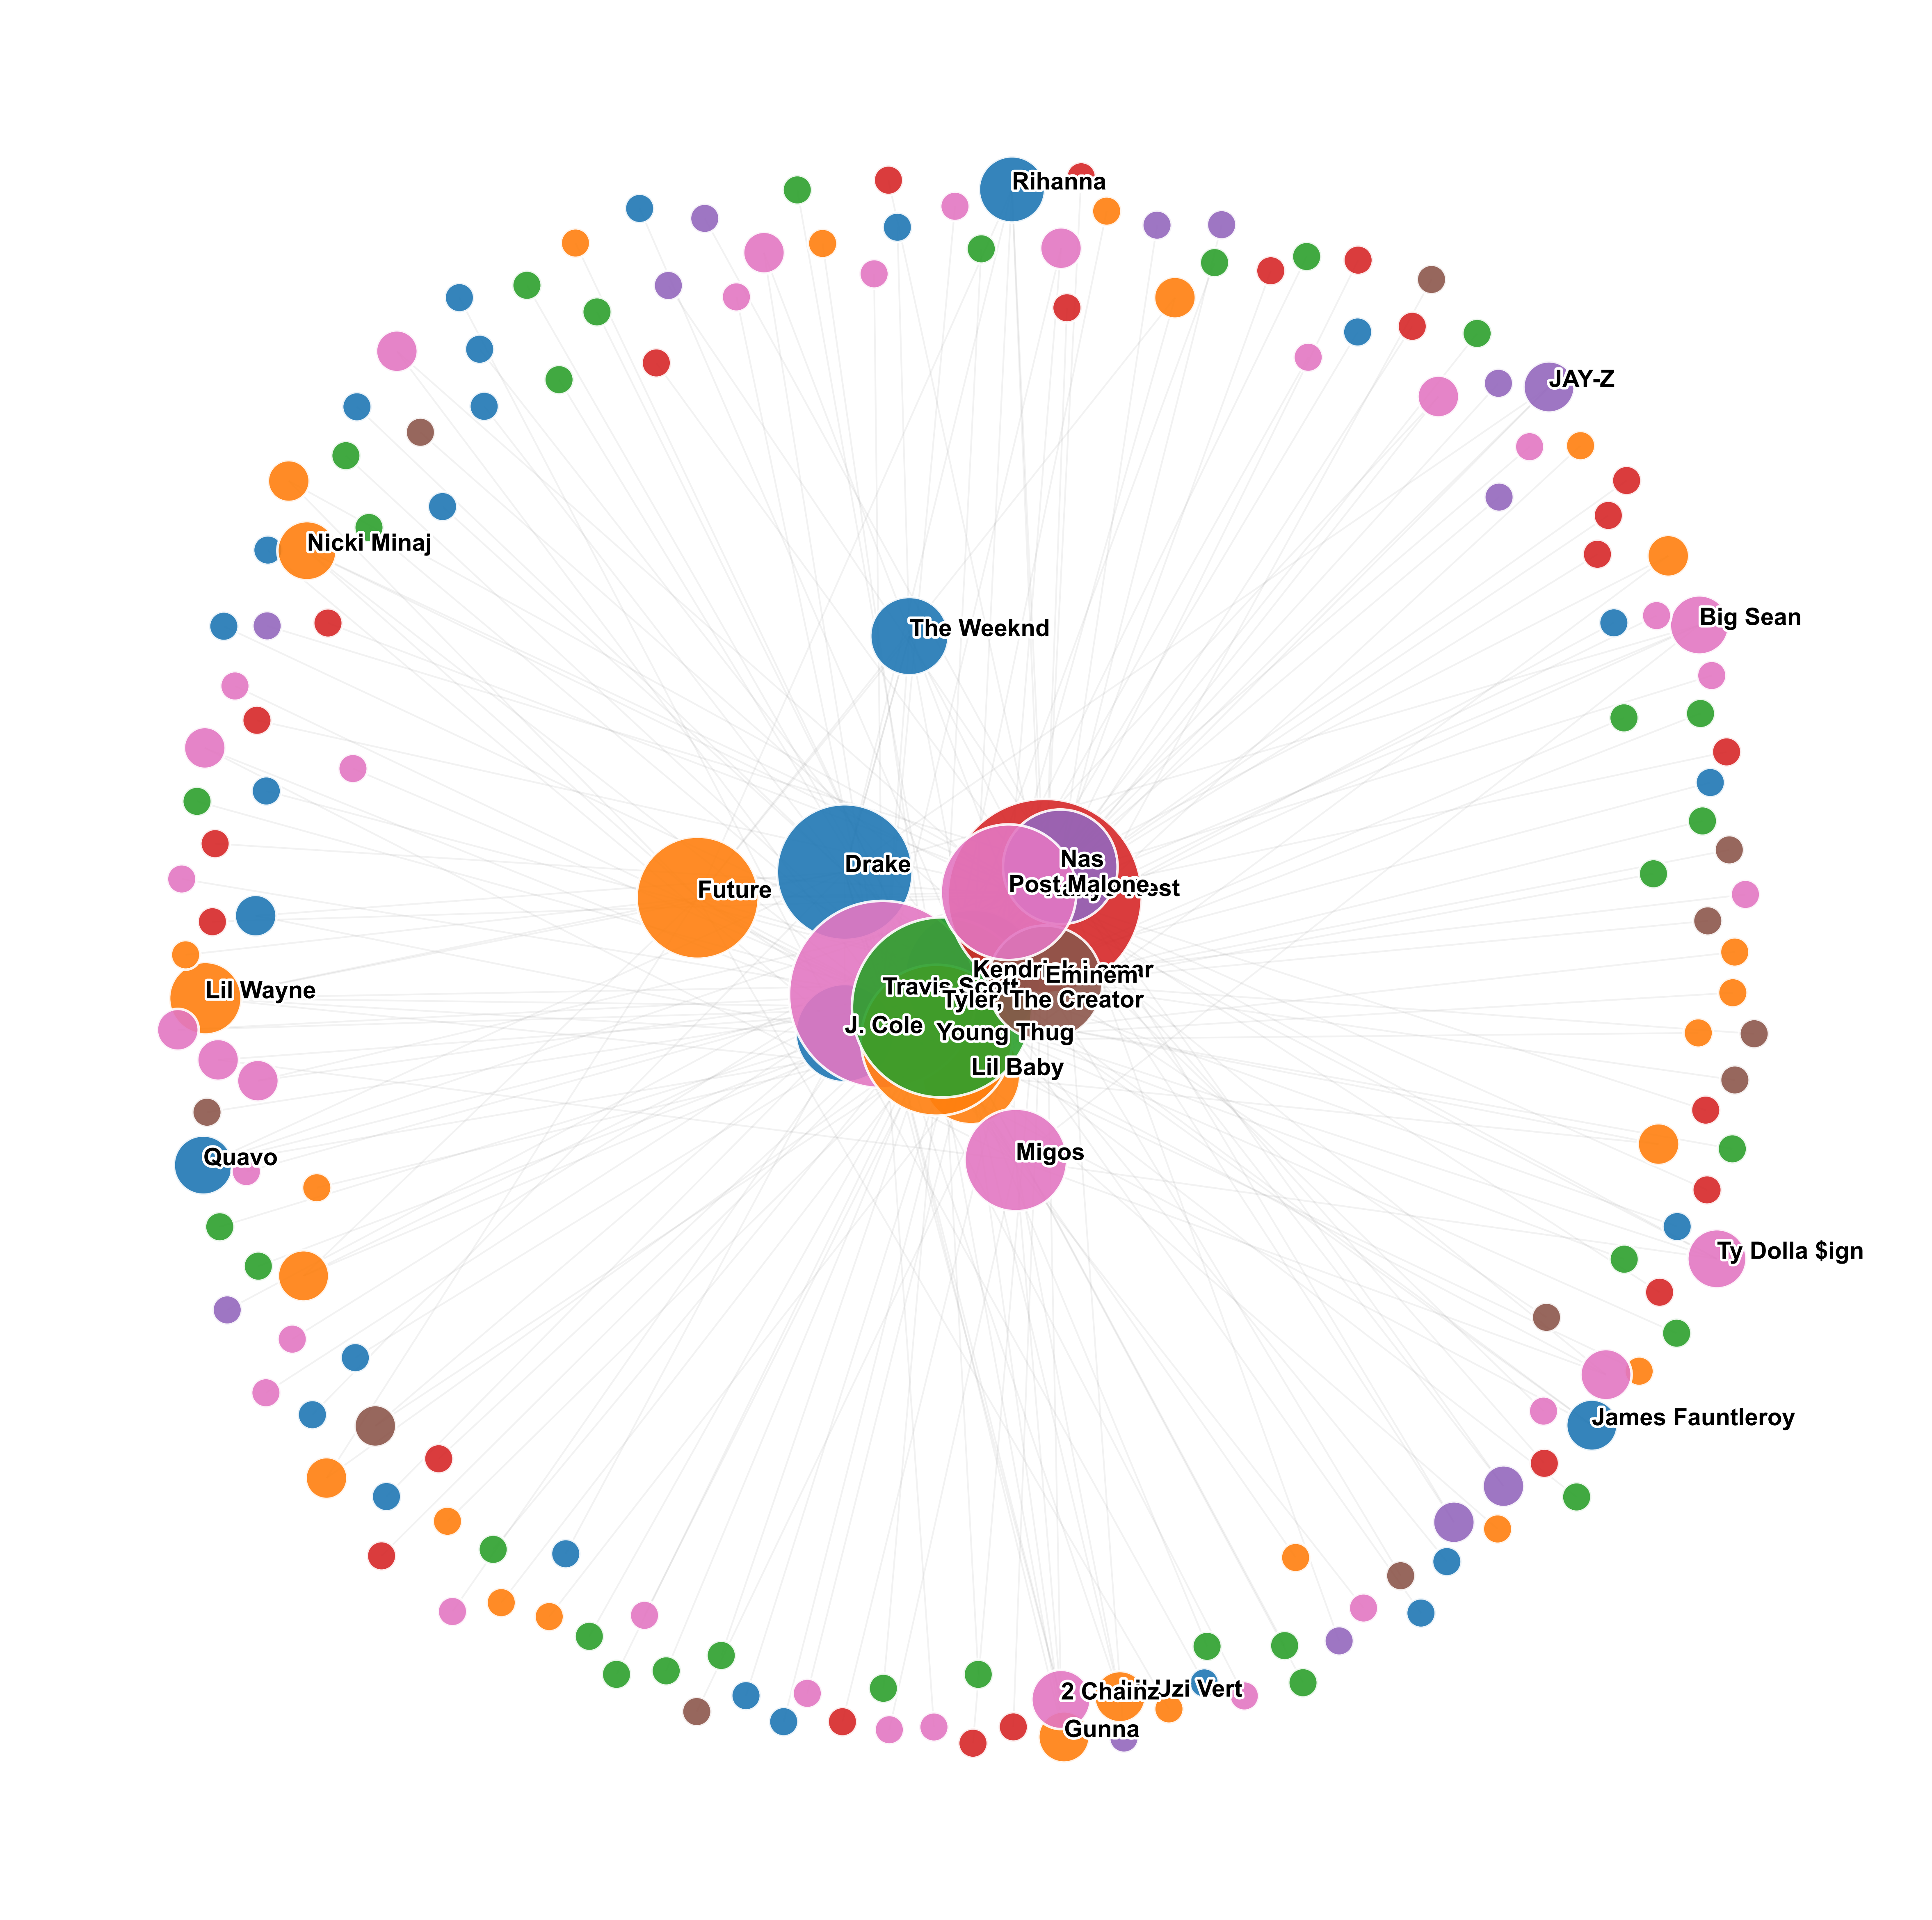

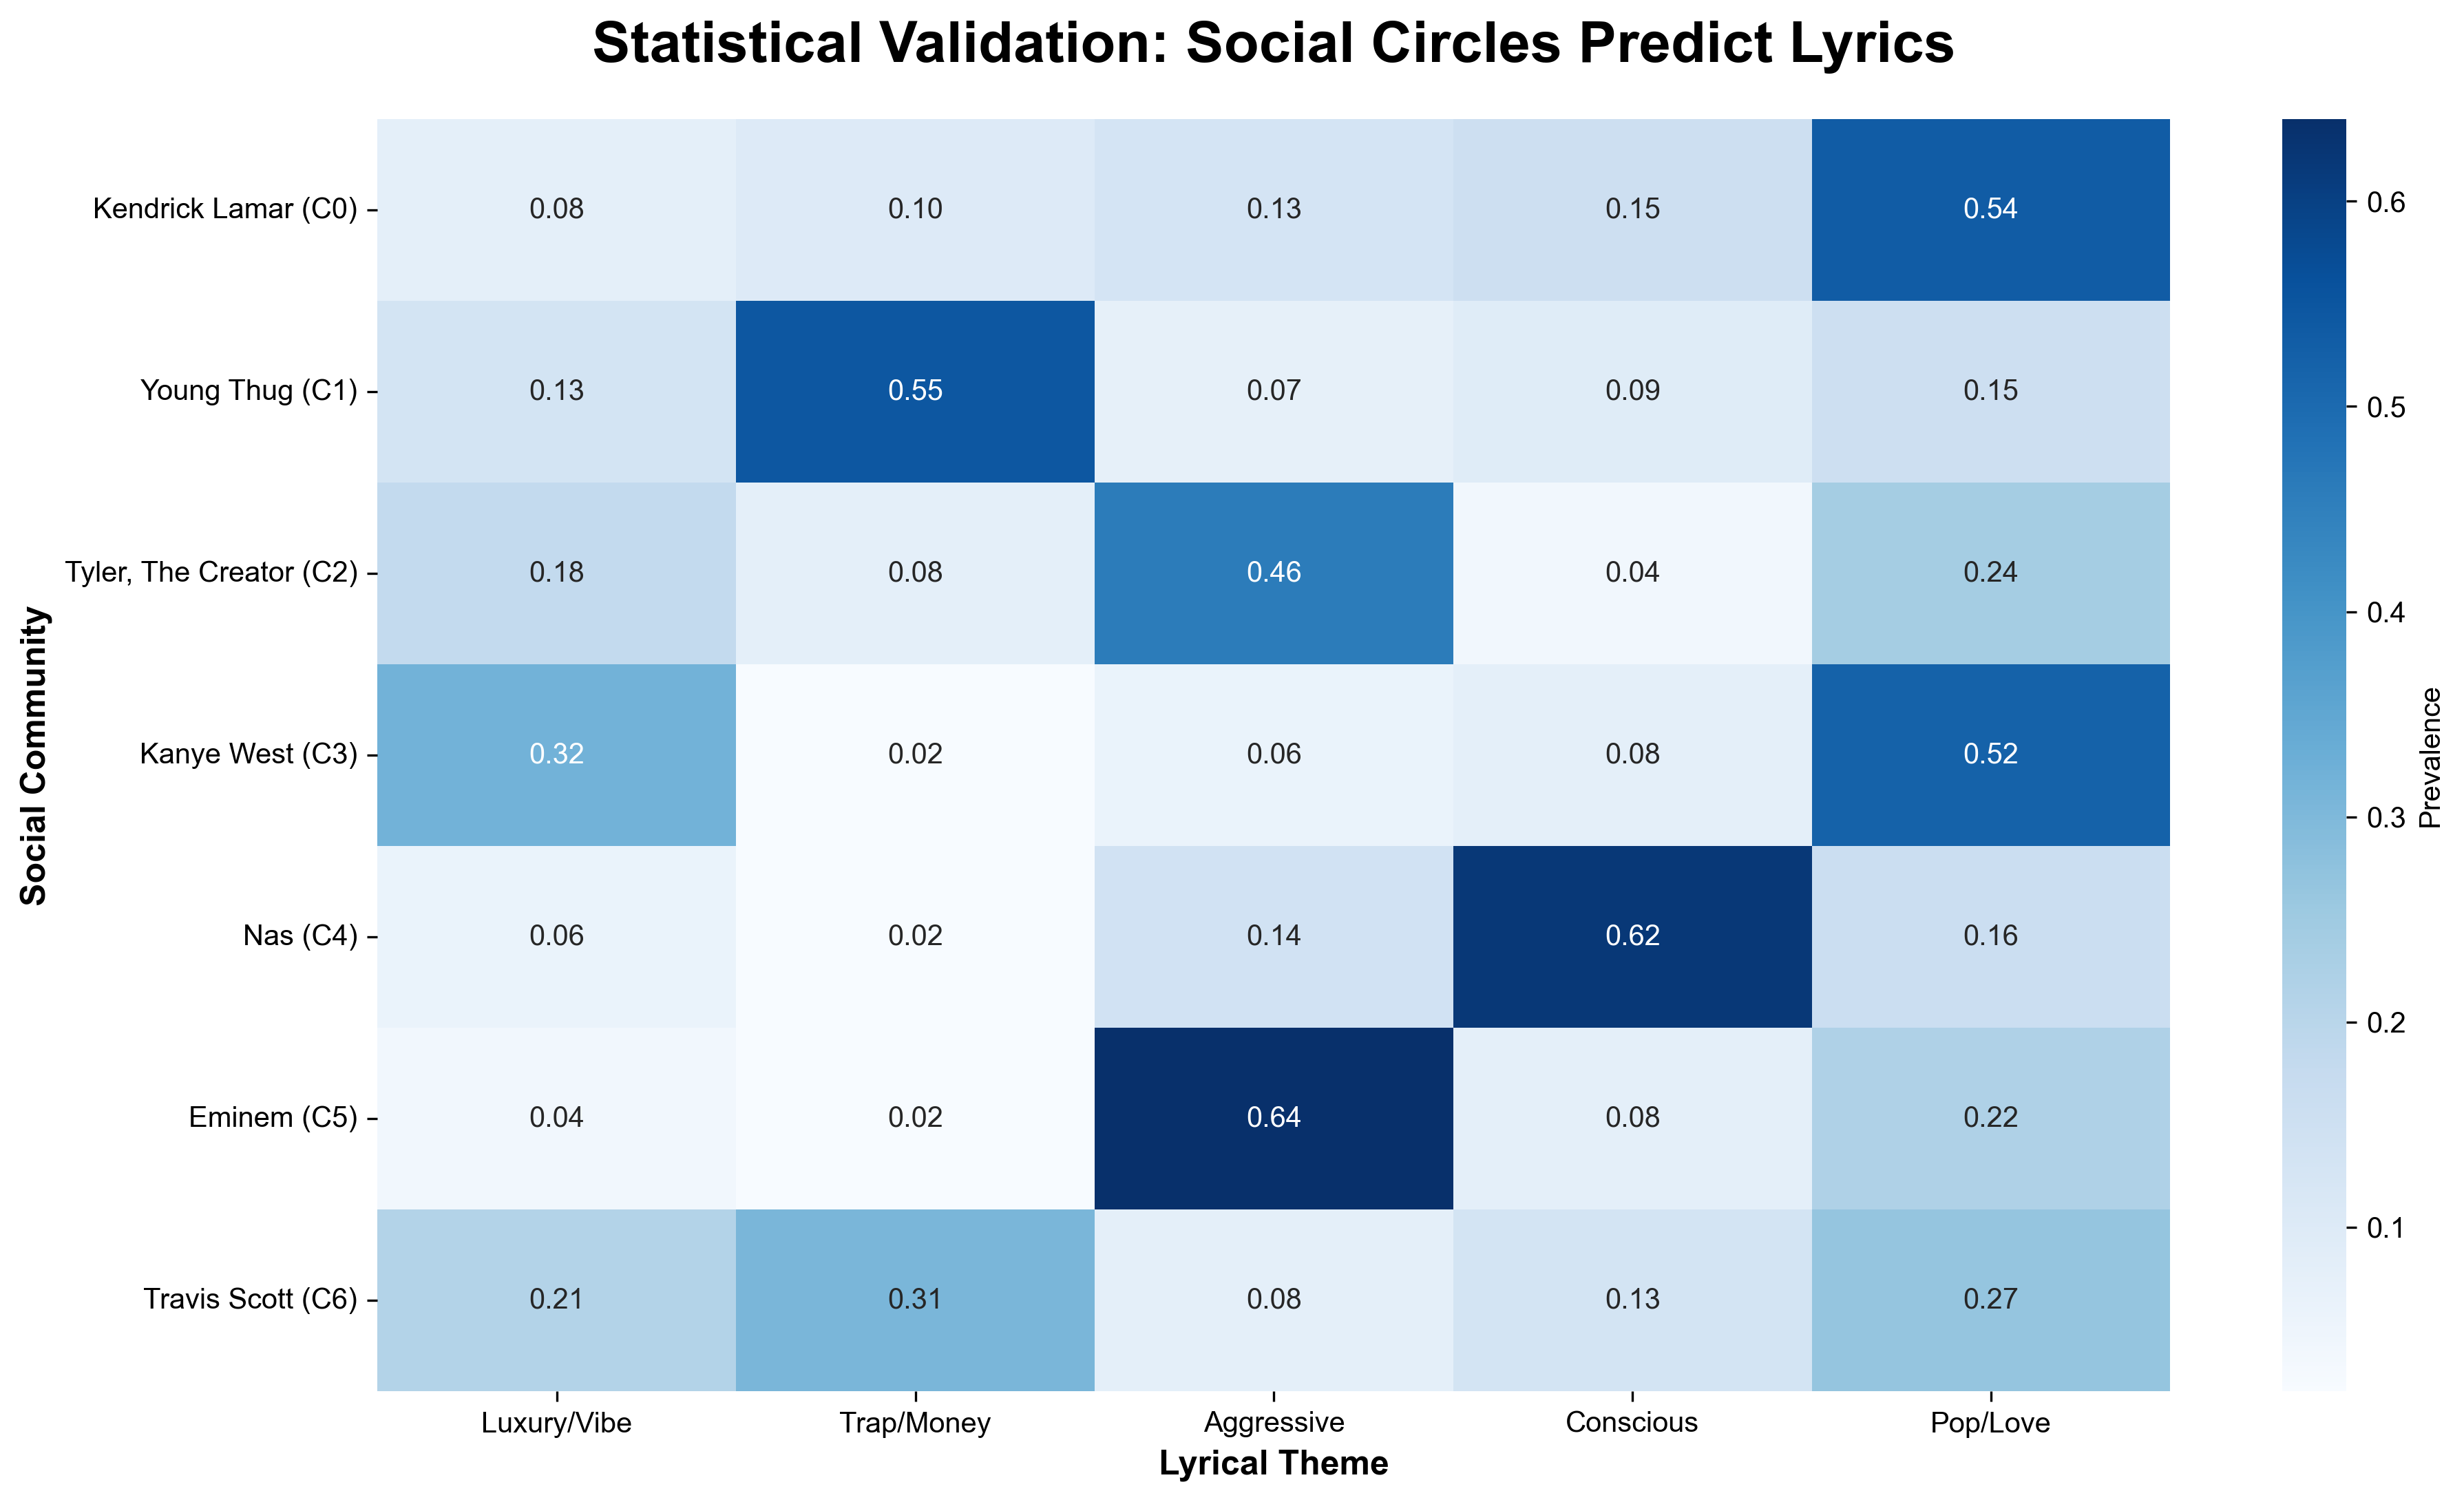

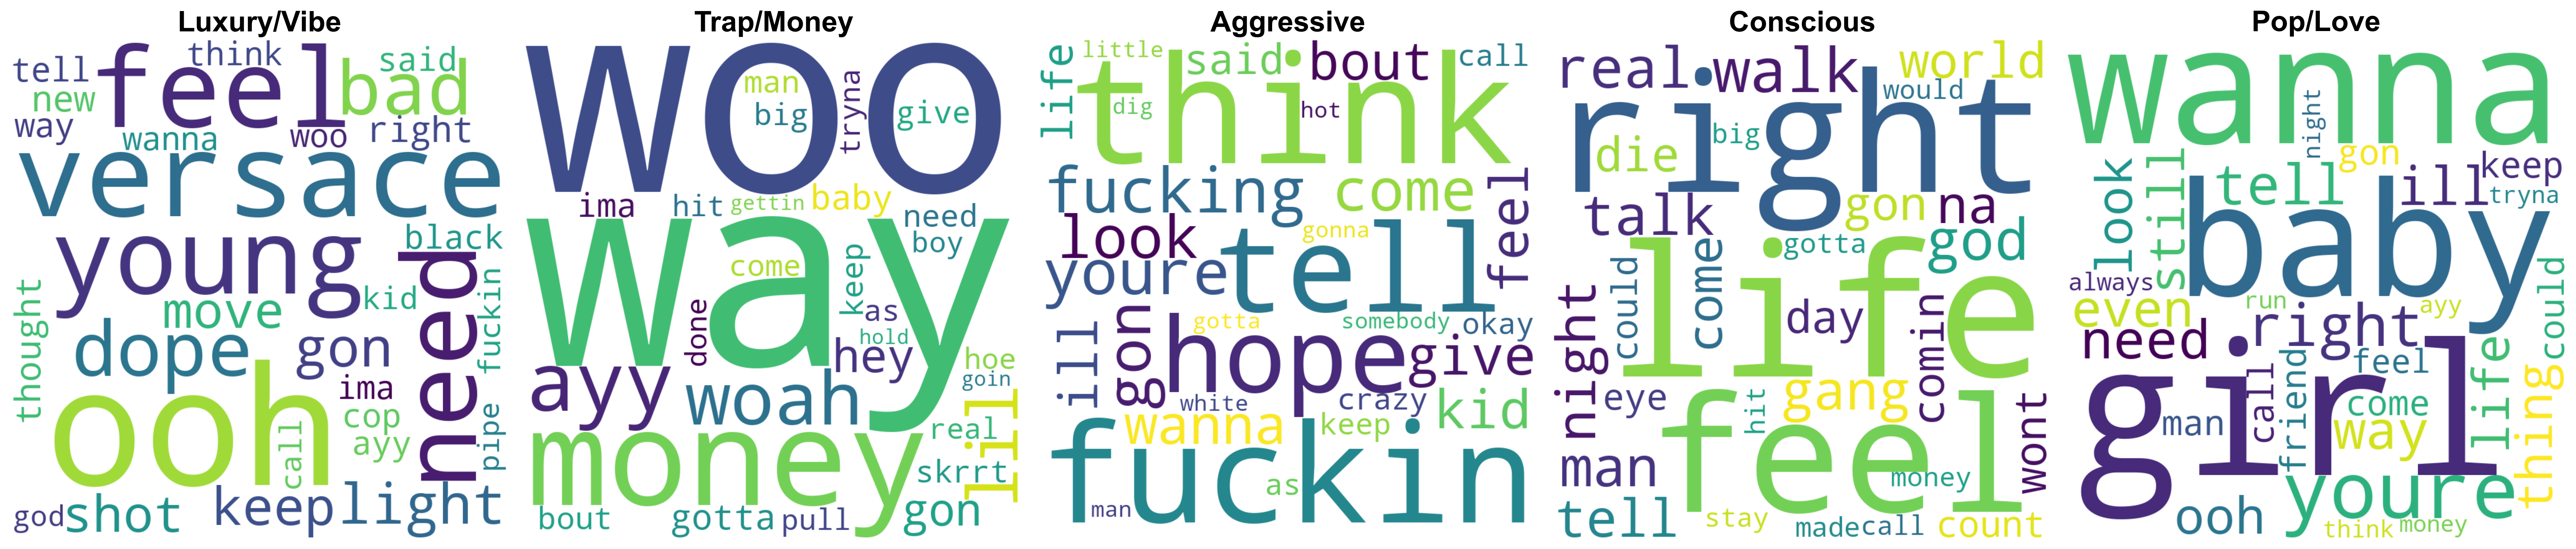

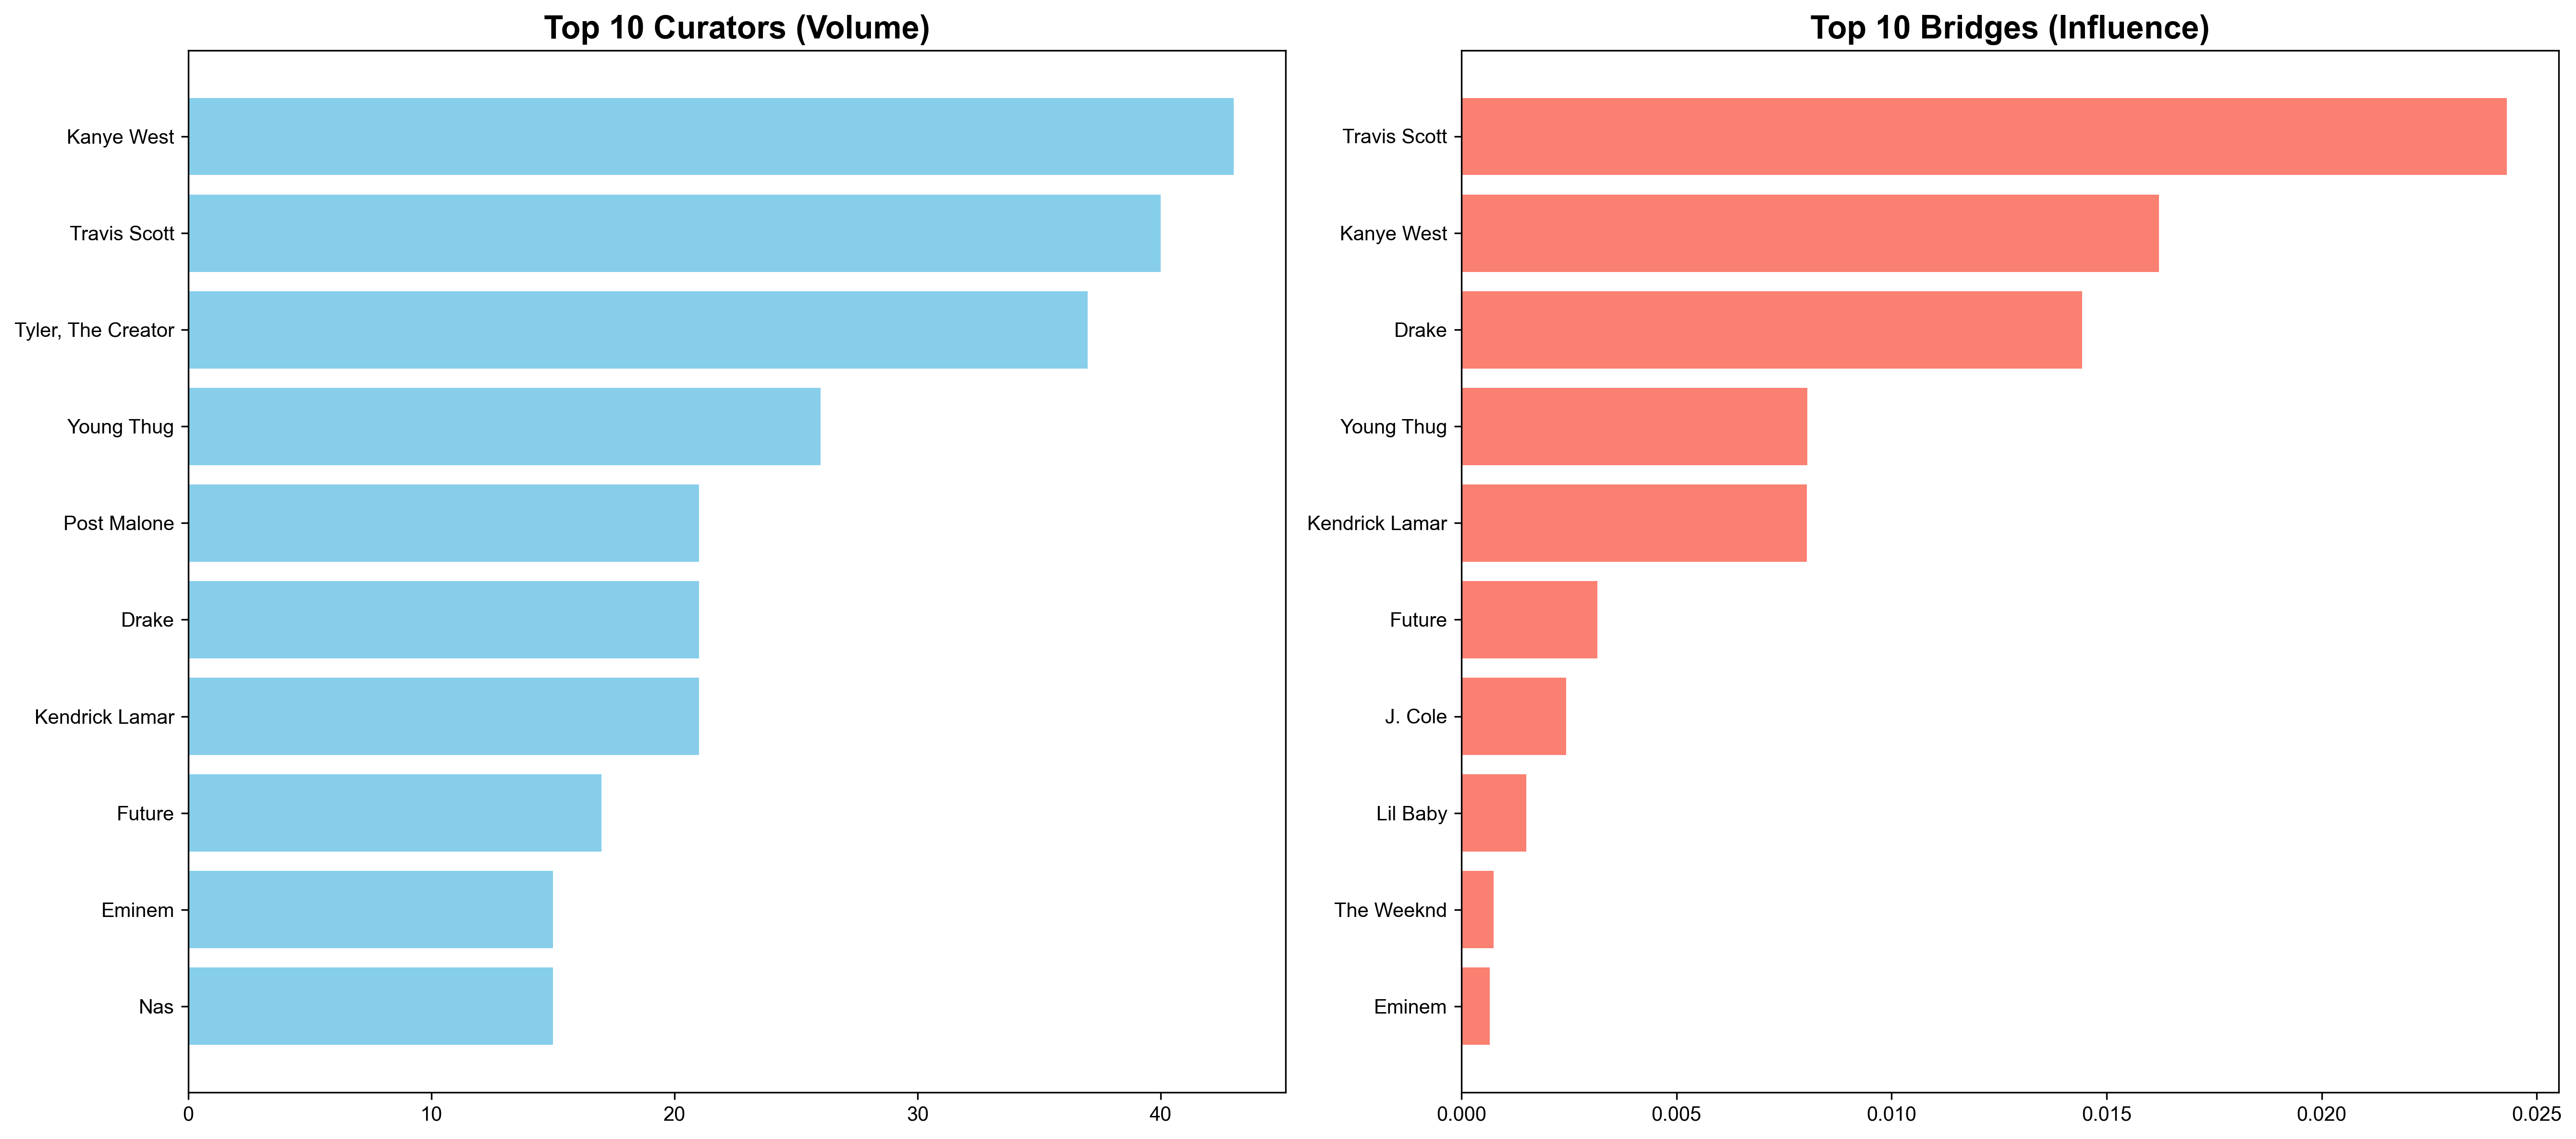

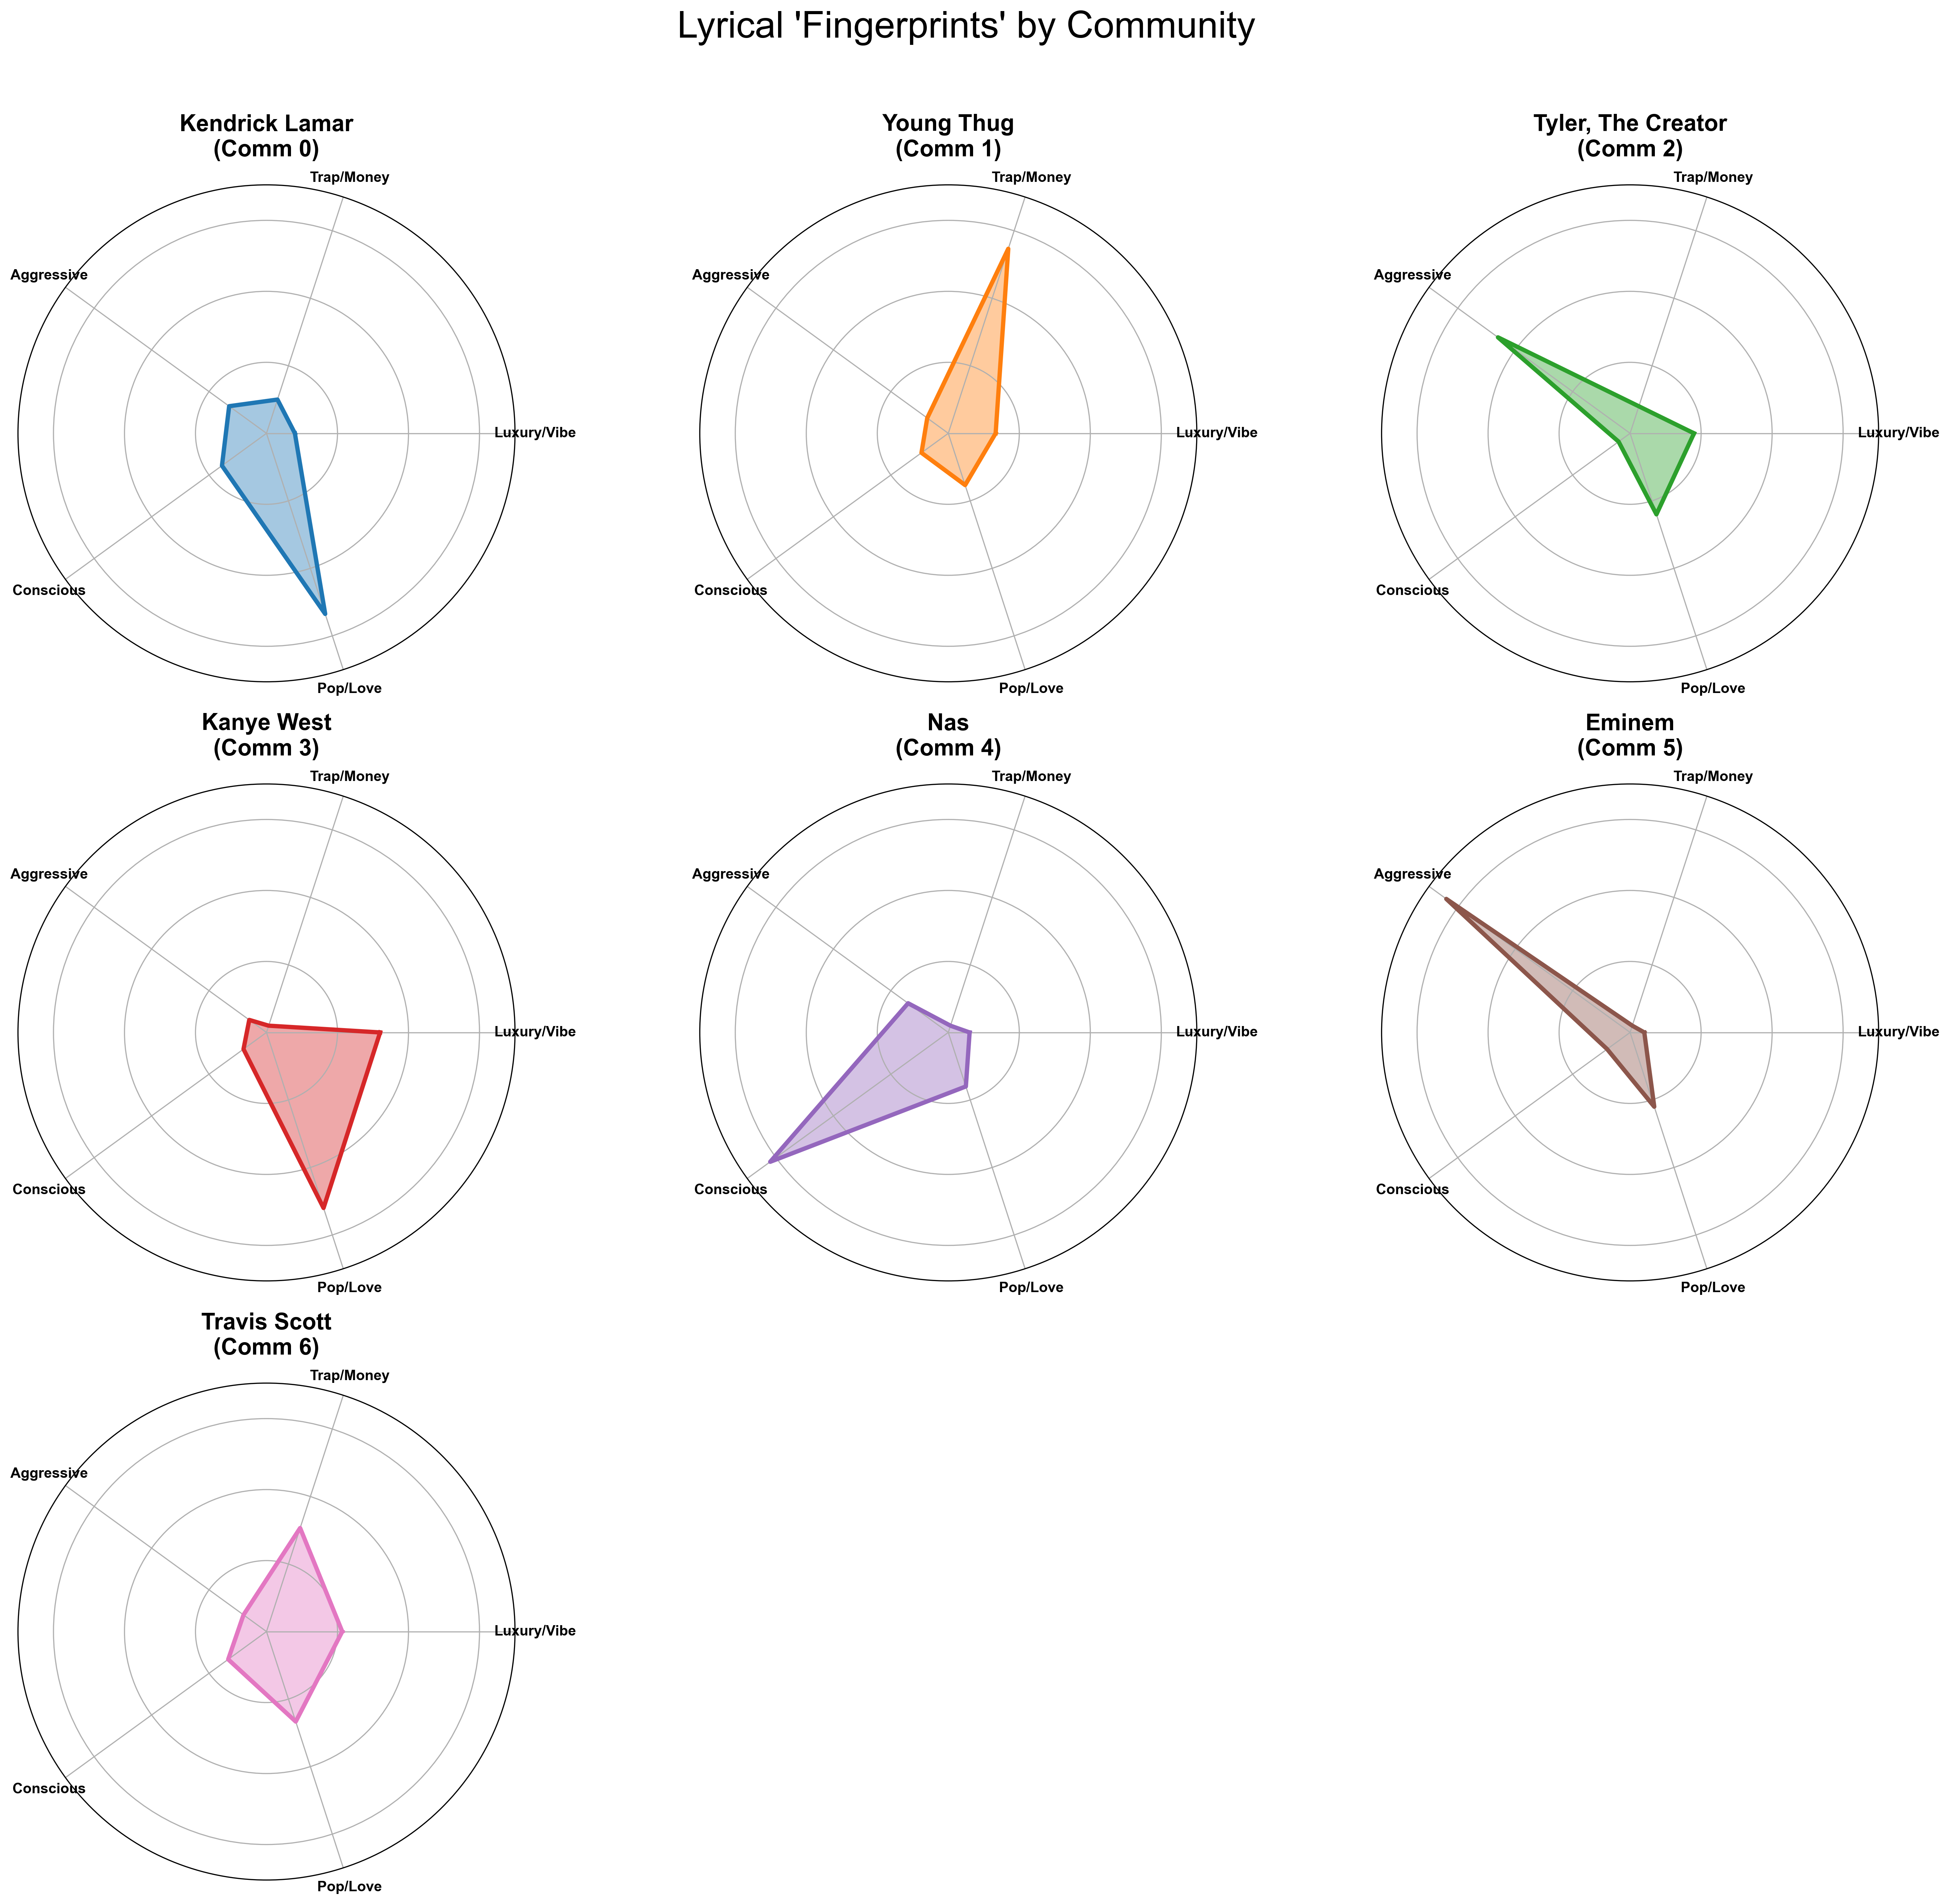

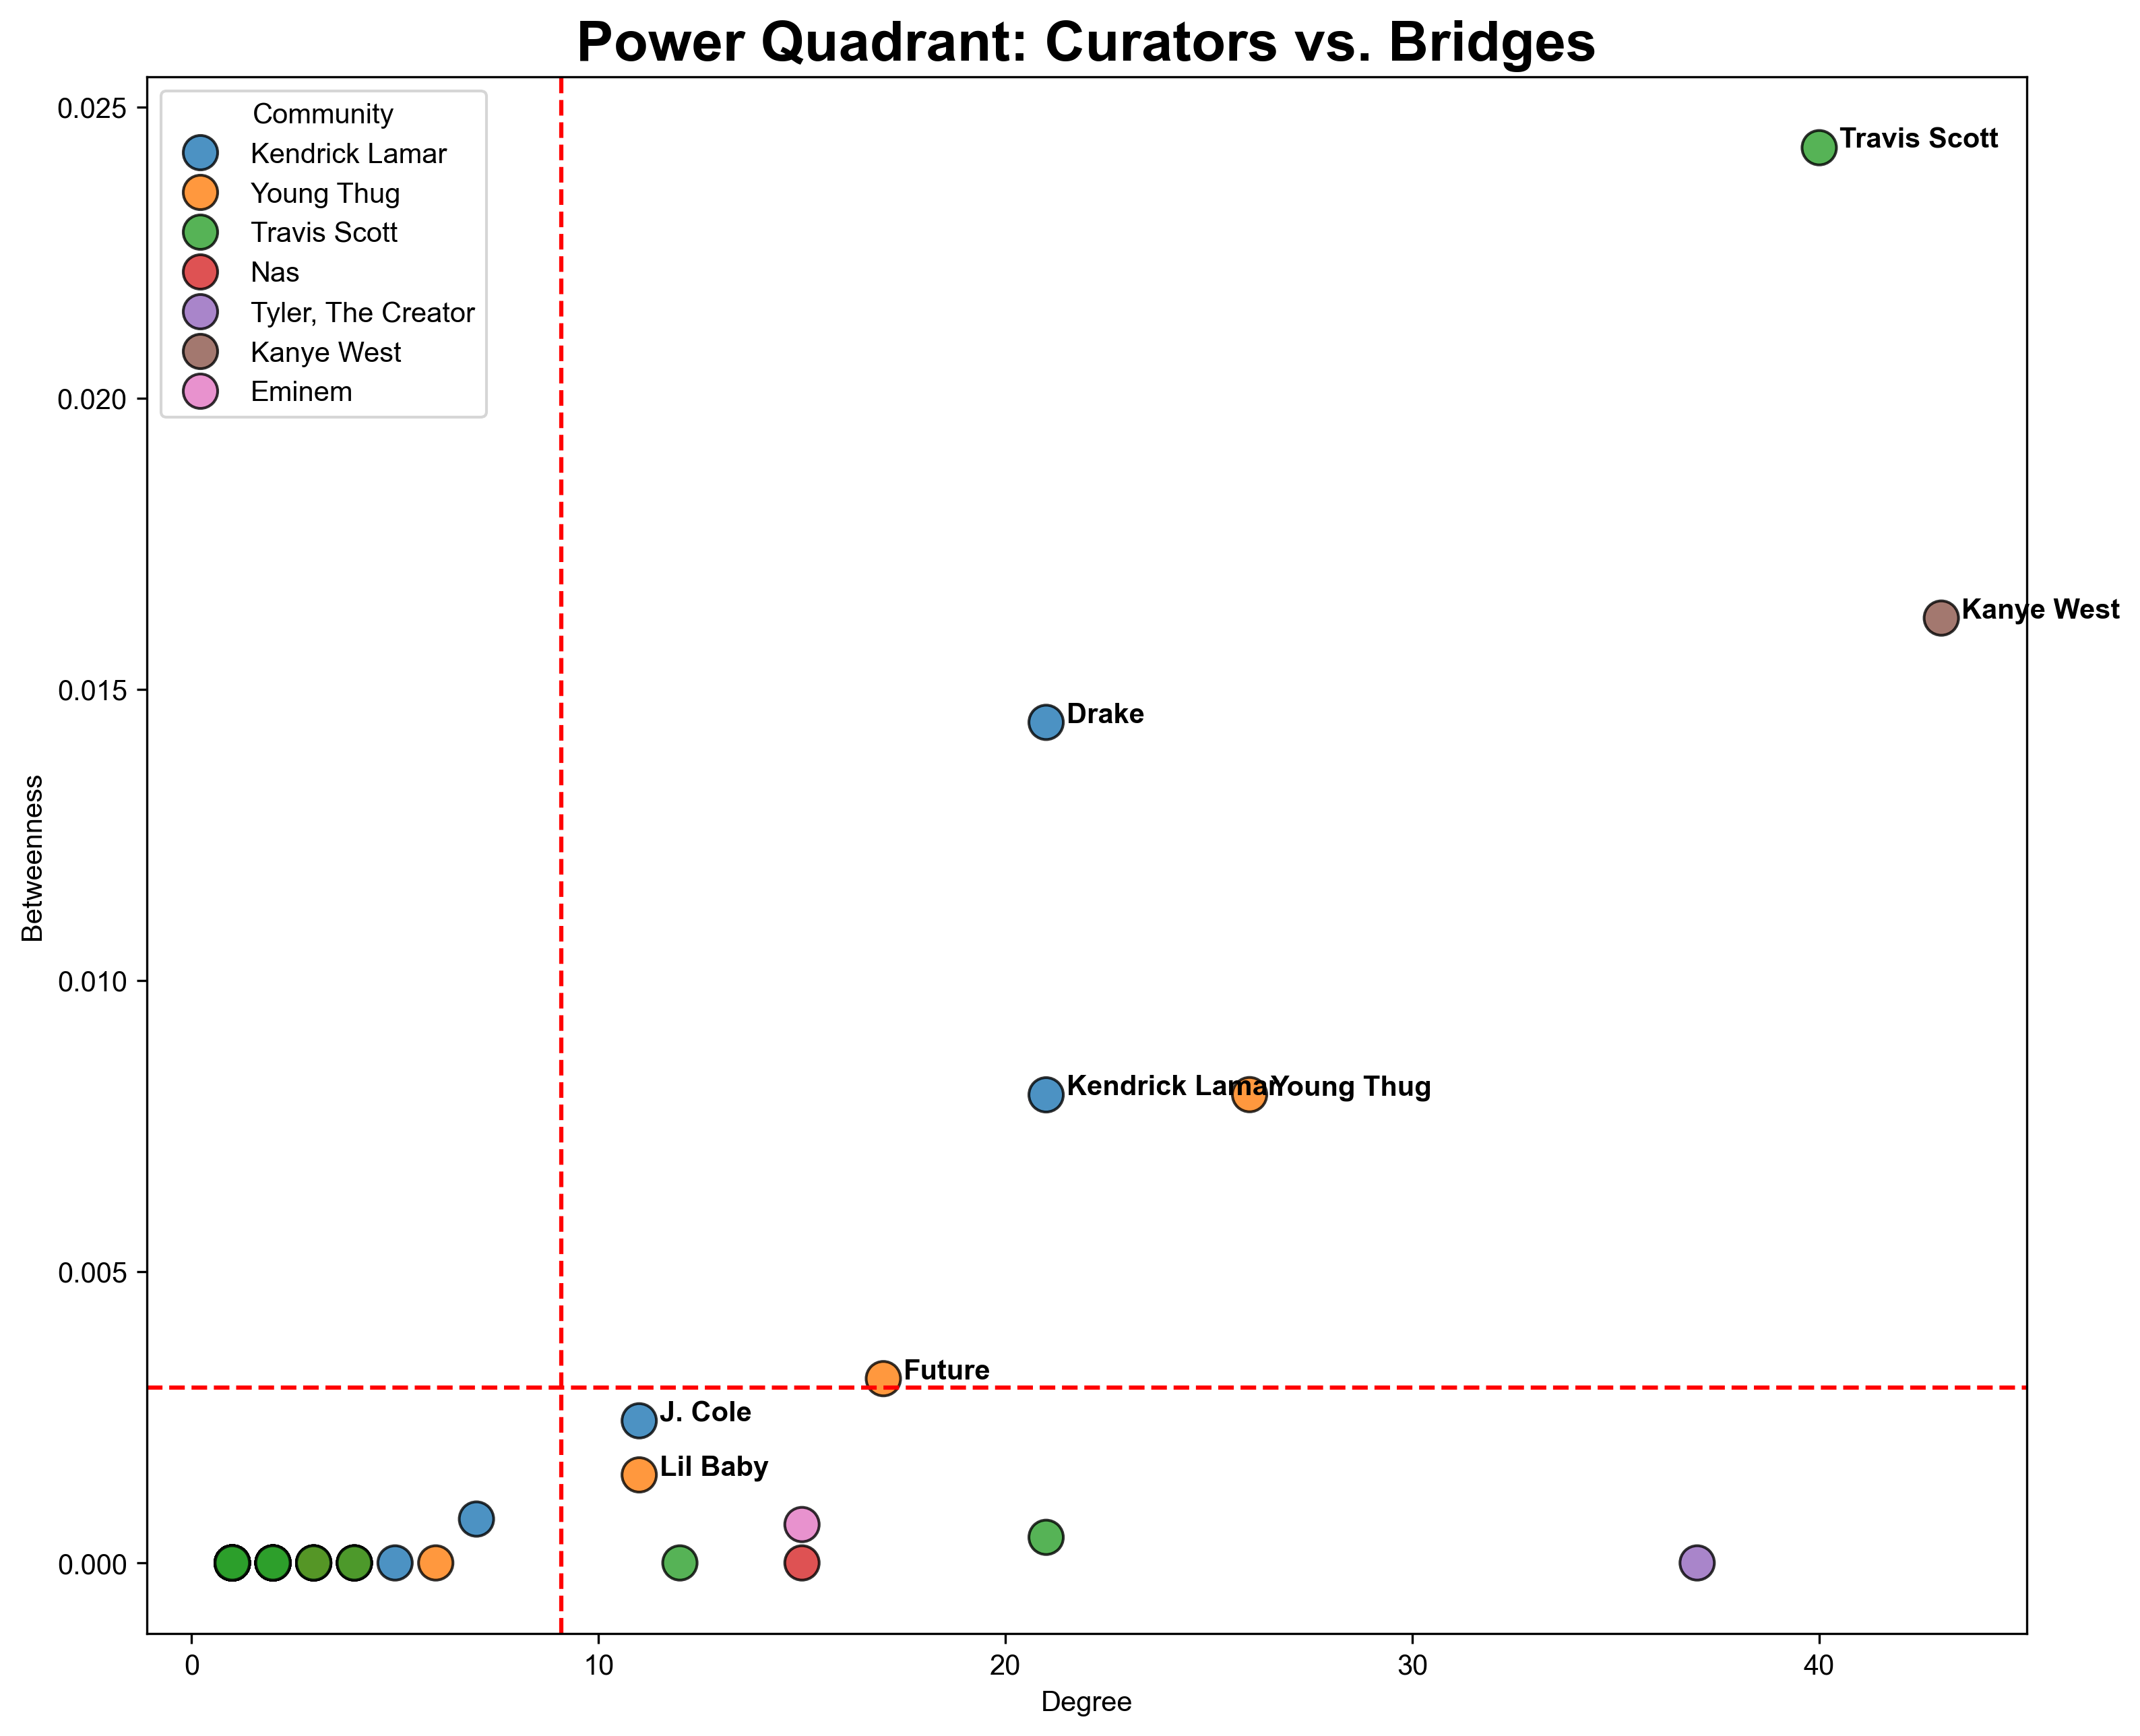

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
import os
import matplotlib.patheffects as path_effects
from gensim.models import LdaMulticore
from matplotlib.patches import Patch

# ==============================================================================
# 1. GLOBAL CONFIGURATION & DESIGN SYSTEM
# ==============================================================================
FIGURES_PATH = '../output/figures'
DATA_PATH = '../data/processed'
MODEL_PATH = '../output/models'
os.makedirs(FIGURES_PATH, exist_ok=True)

# Global Style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 300

# Mappings
topic_labels = [
    "Luxury/Vibe", "Trap/Money", "Aggressive", "Conscious", "Pop/Love"
]

leader_map = {
    0: "Kendrick Lamar", 1: "Young Thug", 2: "Tyler, The Creator",
    3: "Kanye West", 4: "Nas", 5: "Eminem", 6: "Travis Scott"
}

# Unified Palette (Tab10)
palette = sns.color_palette("tab10", 7)
comm_colors = {i: palette[i] for i in range(7)}

print("🎨 Design System Initialized.")

# ==============================================================================
# 2. DATA LOADING
# ==============================================================================
try:
    print("🔄 Loading Data...")
    df_edges = pd.read_csv(os.path.join(DATA_PATH, 'network_edges.csv'))
    df_topics = pd.read_csv(os.path.join(DATA_PATH, 'song_topics.csv'))
    df_comms = pd.read_csv(os.path.join(DATA_PATH, 'artist_communities.csv'))
    
    # Merge
    df_merged = pd.merge(df_topics, df_comms, left_on='artist', right_on='Artist', how='inner')
    
    # Graph & Metrics
    G = nx.from_pandas_edgelist(df_edges, 'source', 'target', create_using=nx.DiGraph())
    degree_dict = dict(G.degree())
    betweenness_dict = nx.betweenness_centrality(G)
    
    # Map Artist -> Community
    node_comm_map = pd.Series(df_comms.Community_ID.values, index=df_comms.Artist).to_dict()
    
    # Load NLP Model
    lda_model = LdaMulticore.load(os.path.join(MODEL_PATH, 'lda_model'))
    
    print("✅ Data Ready.")
except Exception as e:
    print(f"❌ Error: {e}")

# ==============================================================================
# 3. FIGURE 1: THE NETWORK MAP (SOLAR SYSTEM)
# ==============================================================================
def plot_network():
    print("   ...Plotting Network Map")
    plt.figure(figsize=(20, 20))
    pos = nx.spring_layout(G, k=0.25, iterations=50, seed=42)
    
    colors = [comm_colors.get(node_comm_map.get(n, 0), 'grey') for n in G.nodes()]
    sizes = [degree_dict.get(n, 1) * 300 for n in G.nodes()]
    
    nx.draw_networkx_edges(G, pos, alpha=0.1, edge_color='gray', arrows=False)
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, alpha=0.9, edgecolors='white', linewidths=1.5)
    
    # Label Top 25
    top_hubs = sorted(degree_dict, key=degree_dict.get, reverse=True)[:25]
    for node, (x, y) in pos.items():
        if node in top_hubs:
            txt = plt.text(x, y, node, fontsize=14, fontweight='bold', color='black')
            txt.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])
            
    plt.axis('off')
    plt.savefig(os.path.join(FIGURES_PATH, 'network_visualization.png'), bbox_inches='tight')

# ==============================================================================
# 4. FIGURE 2: HEATMAP (STATISTICAL VALIDATION)
# ==============================================================================
def plot_heatmap():
    print("   ...Plotting Heatmap")
    topic_dist = pd.crosstab(df_merged['Community_ID'], df_merged['Dominant_Topic'], normalize='index')
    
    plt.figure(figsize=(14, 8))
    y_labels = [f"{leader_map.get(i)} (C{i})" for i in topic_dist.index]
    
    sns.heatmap(topic_dist, annot=True, fmt=".2f", cmap="Blues", 
                xticklabels=topic_labels, yticklabels=y_labels,
                cbar_kws={'label': 'Prevalence'})
    
    plt.title("Statistical Validation: Social Circles Predict Lyrics", fontsize=20, pad=20)
    plt.xlabel("Lyrical Theme", fontsize=12, fontweight='bold')
    plt.ylabel("Social Community", fontsize=12, fontweight='bold')
    plt.yticks(rotation=0)
    plt.savefig(os.path.join(FIGURES_PATH, 'community_topic_heatmap.png'), bbox_inches='tight')

# ==============================================================================
# 5. FIGURE 3: RADAR CHARTS (FINGERPRINTS)
# ==============================================================================
def plot_radars():
    print("   ...Plotting Radar Charts")
    topic_dist = pd.crosstab(df_merged['Community_ID'], df_merged['Dominant_Topic'], normalize='index')
    
    num_vars = len(topic_labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, axes = plt.subplots(figsize=(20, 18), subplot_kw=dict(polar=True), nrows=3, ncols=3)
    axes = axes.flatten()
    
    for i, comm_id in enumerate(topic_dist.index):
        if i >= len(axes): break
        ax = axes[i]
        stats = topic_dist.loc[comm_id].values.tolist()
        stats += stats[:1]
        
        # Color matches the community color from the network map!
        c = comm_colors[comm_id]
        
        ax.plot(angles, stats, linewidth=3, linestyle='solid', color=c)
        ax.fill(angles, stats, color=c, alpha=0.4)
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(topic_labels, fontsize=10, fontweight='bold')
        ax.set_yticks([0.2, 0.4, 0.6])
        ax.set_yticklabels(["", "", ""], color="grey") # Clean look
        ax.set_ylim(0, 0.7)
        ax.set_title(f"{leader_map.get(comm_id)}\n(Comm {comm_id})", size=16, weight='bold', pad=20, color='black')

    for j in range(len(topic_dist), len(axes)): axes[j].axis('off')
    plt.suptitle("Lyrical 'Fingerprints' by Community", fontsize=26, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, 'community_radar_charts.png'), bbox_inches='tight')

# ==============================================================================
# 6. FIGURE 4: BAR CHARTS (CENTRALITY)
# ==============================================================================
def plot_bars():
    print("   ...Plotting Bar Charts")
    data = [{'Artist': n, 'Degree': degree_dict[n], 'Betweenness': betweenness_dict[n]} for n in G.nodes()]
    df_metrics = pd.DataFrame(data)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Top Degree
    top_deg = df_metrics.nlargest(10, 'Degree').sort_values('Degree')
    ax1.barh(top_deg['Artist'], top_deg['Degree'], color='#87CEEB') # SkyBlue
    ax1.set_title('Top 10 Curators (Volume)', fontsize=16)
    
    # Top Betweenness
    top_bet = df_metrics.nlargest(10, 'Betweenness').sort_values('Betweenness')
    ax2.barh(top_bet['Artist'], top_bet['Betweenness'], color='#FA8072') # Salmon
    ax2.set_title('Top 10 Bridges (Influence)', fontsize=16)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, 'centrality_bar_charts.png'), bbox_inches='tight')

# ==============================================================================
# 7. FIGURE 5: WORD CLOUDS
# ==============================================================================
def plot_wordclouds():
    print("   ...Plotting Word Clouds")
    topics = lda_model.show_topics(num_topics=5, num_words=30, formatted=False)
    fig, axes = plt.subplots(1, 5, figsize=(25, 6))
    
    for i, (topic_id, words) in enumerate(topics):
        ax = axes[i]
        word_dict = {w: p for w, p in words}
        wc = WordCloud(width=800, height=800, background_color='white', colormap='viridis').generate_from_frequencies(word_dict)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"{topic_labels[i]}", fontsize=20, fontweight='bold')
        ax.axis('off')
        
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, 'topic_word_clouds.png'), bbox_inches='tight')

# ==============================================================================
# 8. FIGURE 6: EGO NETWORKS (STRATEGIC ROLES)
# ==============================================================================
def plot_egos():
    print("   ...Plotting Ego Networks")
    target_egos = ["Travis Scott", "J. Cole", "Eminem", "Kanye West", "Drake"]
    
    for ego in target_egos:
        if ego not in G: continue
        
        # Create Subgraph (Radius 1)
        nodes = list(G.predecessors(ego)) + list(G.successors(ego)) + [ego]
        subG = G.subgraph(nodes)
        
        plt.figure(figsize=(10, 10))
        pos = nx.spring_layout(subG, k=0.5, seed=42)
        
        # Color nodes by their GLOBAL community color
        cols = [comm_colors.get(node_comm_map.get(n, 0), 'grey') for n in subG.nodes()]
        sizes = [3000 if n == ego else 300 for n in subG.nodes()]
        
        nx.draw_networkx_edges(subG, pos, alpha=0.2, edge_color='gray')
        nx.draw_networkx_nodes(subG, pos, node_size=sizes, node_color=cols, alpha=0.9)
        
        # Label all
        texts = []
        for n, (x, y) in pos.items():
            weight = 'bold' if n == ego else 'normal'
            size = 14 if n == ego else 9
            txt = plt.text(x, y, n, fontsize=size, fontweight=weight)
            txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='white')])
            
        plt.title(f"Ego Network: {ego}", fontsize=18)
        plt.axis('off')
        
        # Save safe filename
        safe_name = ego.replace(" ", "_").replace(".", "")
        plt.savefig(os.path.join(FIGURES_PATH, f'ego_network_{safe_name}.png'), bbox_inches='tight')
        plt.close()

# ==============================================================================
# 9. FIGURE 7: NEW! POWER QUADRANT (SCATTER)
# ==============================================================================
def plot_scatter():
    print("   ...Plotting Power Quadrant")
    data = []
    for n in G.nodes():
        cid = node_comm_map.get(n, 0)
        data.append({
            'Artist': n,
            'Degree': degree_dict[n],
            'Betweenness': betweenness_dict[n],
            'Community': leader_map.get(cid, f"C{cid}")
        })
    df_viz = pd.DataFrame(data)
    
    plt.figure(figsize=(12, 10))
    sns.scatterplot(data=df_viz, x='Degree', y='Betweenness', hue='Community', 
                    palette='tab10', s=150, alpha=0.8, edgecolor='black')
    
    # Highlight Bridges & Curators
    plt.axvline(x=df_viz.Degree.mean() + df_viz.Degree.std(), color='red', linestyle='--')
    plt.axhline(y=df_viz.Betweenness.mean() + df_viz.Betweenness.std(), color='red', linestyle='--')
    
    # Label top points
    top_pts = df_viz.nlargest(8, 'Betweenness')
    for _, row in top_pts.iterrows():
        plt.text(row.Degree+0.5, row.Betweenness, row.Artist, fontsize=10, fontweight='bold')
        
    plt.title("Power Quadrant: Curators vs. Bridges", fontsize=20)
    plt.savefig(os.path.join(FIGURES_PATH, 'centrality_scatter.png'), bbox_inches='tight')

# ==============================================================================
# EXECUTE ALL
# ==============================================================================
if 'G' in locals():
    plot_network()
    plot_heatmap()
    plot_wordclouds()
    plot_bars()
    plot_radars()
    plot_egos()
    plot_scatter()
    print("\n✅ MASTER OVERHAUL COMPLETE. All 10+ figures generated.")